# Proyecto: Análisis de Salud Mental en Adolecentes por uso de Social Media
## Autor: Diego Castro

In [111]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB

In [13]:
# Lectura y vista del dataset
data = pd.read_csv('Teen_Mental_Health_Dataset.csv')
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### Datos generales

In [ ]:
data.shape # Cuantas filas y columnas tiene el dataset
data.info() # Información general del dataset

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [ ]:
data.describe() # Estadísticas descriptivas de las variables numéricas

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [14]:
# Valores nulos
data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

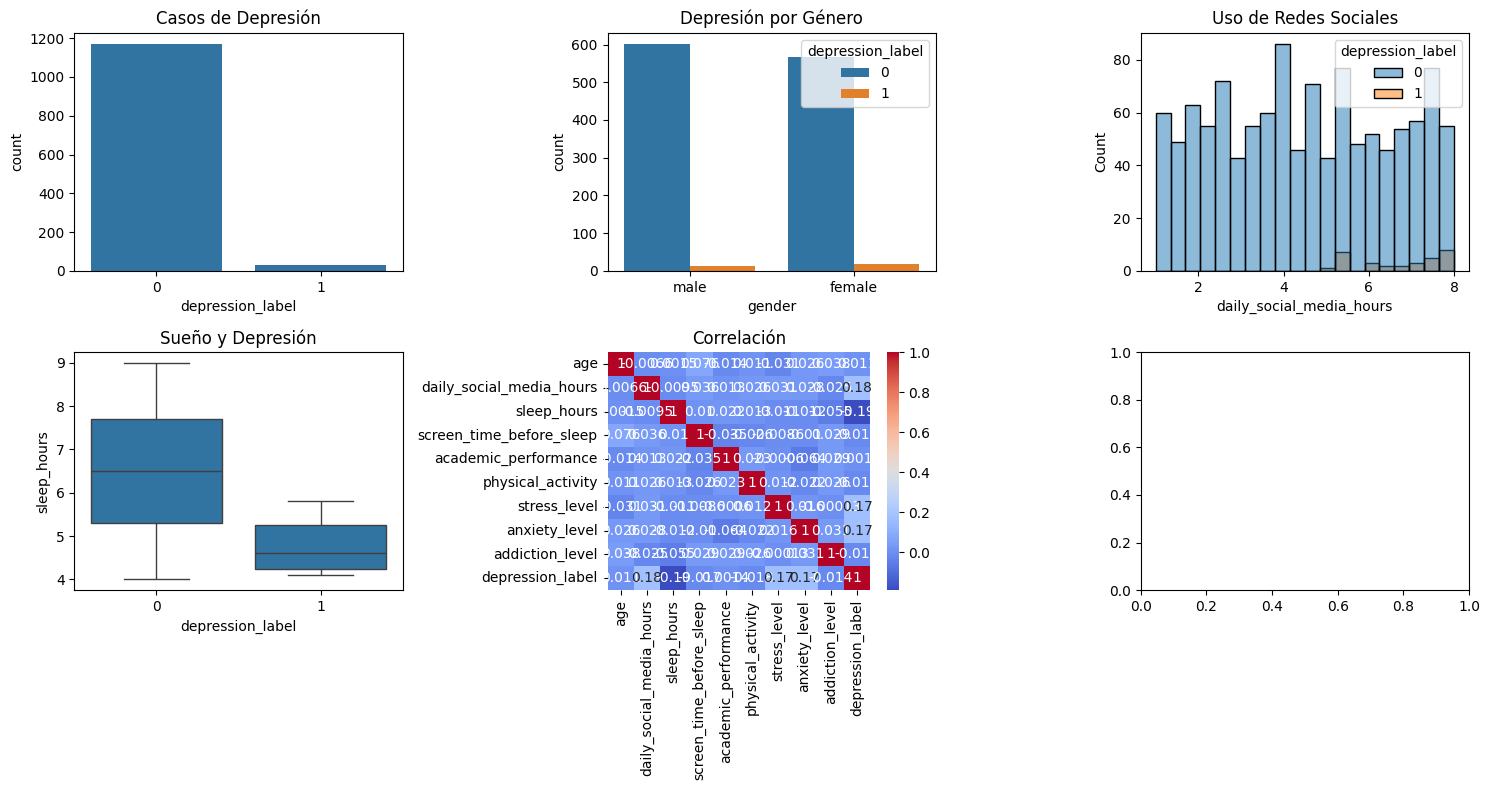

In [132]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.countplot(
    x="depression_label",
    data=data,
    ax=axes[0,0]
)
axes[0,0].set_title("Casos de Depresión")
sns.countplot(
    x="gender",
    hue="depression_label",
    data=data,
    ax=axes[0,1]
)
axes[0,1].set_title("Depresión por Género")
sns.histplot(
    data=data,
    x="daily_social_media_hours",
    hue="depression_label",
    bins=20,
    ax=axes[0,2]
)
axes[0,2].set_title("Uso de Redes Sociales")
sns.boxplot(
    x="depression_label",
    y="sleep_hours",
    data=data,
    ax=axes[1,0]
)
axes[1,0].set_title("Sueño y Depresión")
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    ax=axes[1,1]
)
axes[1,1].set_title("Correlación")
plt.tight_layout()
plt.show()

## Regresión Logistica

In [17]:
x = data.drop("depression_label", axis=1)
y = data["depression_label"]
x.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2


In [21]:
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns
print("Columnas numéricas:", numerical_features)
print("Columnas categóricas:", categorical_features)

Columnas numéricas: Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level'],
      dtype='str')
Columnas categóricas: Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='str')


/var/folders/r4/mgkrh5bj69q4qmwxnclqj6zm0000gn/T/ipykernel_2144/1983191772.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(include=['object']).columns


In [42]:
x = pd.get_dummies(x, drop_first=True)
print("Dimensiones:", x.shape)
x.head()

Dimensiones: (1200, 14)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,True,True,False,True,False
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,False,False,True,False,False
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,False,True,False,False,False
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,True,False,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,False,False,False,False,True


In [44]:
print(x.columns.tolist())

['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']


In [45]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled.shape

(1200, 14)

In [48]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(x_train.shape)
print(x_test.shape)

(960, 14)
(240, 14)


In [53]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
#Predicción
y_pred = modelo.predict(x_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [73]:
# Accuracy
acc_log= accuracy_score(y_test, y_pred)
print("Accuracy:", acc_log)

Accuracy: 0.9875


In [74]:
# Presición, Recall y F1-Score
prec_log = precision_score(y_test, y_pred)
rec_log = recall_score(y_test, y_pred)
f1_log = f1_score(y_test, y_pred)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666


In [ ]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



In [ ]:
# Matriz de confusión   
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

[[234   0]
 [  3   3]]


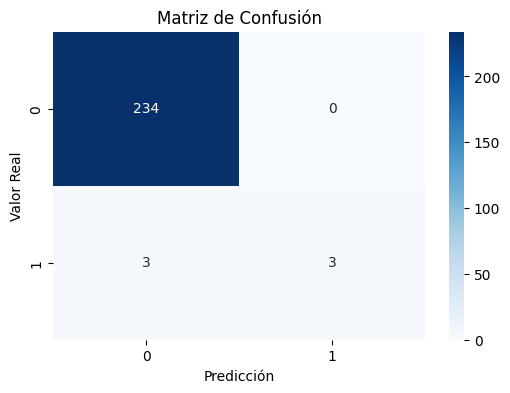

In [62]:
# Grafico de la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

## Random Forest

In [63]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
modelo_rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
#Predicciones del Random Forest
y_pred_rf = modelo_rf.predict(x_test)
y_pred_rf[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [67]:
# Accuracy, Precision, Recall y F1-Score para Random Forest
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9791666666666666
Precision: 1.0
Recall: 0.16666666666666666
F1 Score: 0.2857142857142857


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



In [ ]:
# Matriz de confusión de Random Forest
matrix_rf = confusion_matrix(y_test, y_pred_rf)
print(matrix_rf)

[[234   0]
 [  5   1]]


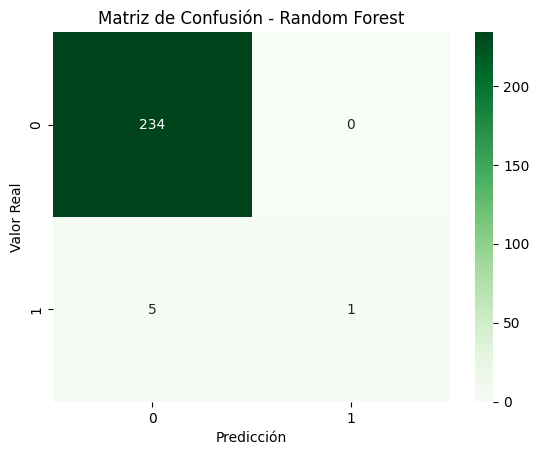

In [70]:
# Gráfico de la matriz de confusión de Random Forest
sns.heatmap(matrix_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [76]:
# Accuracy, Precision, Recall y F1-Score para Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)


## Naive Bayes

In [127]:
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)

In [128]:
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
print("Accuracy:", acc_nb)
print("Precision:", prec_nb)
print("Recall:", rec_nb)
print("F1:", f1_nb)

Accuracy: 0.9875
Precision: 1.0
Recall: 0.5
F1: 0.6666666666666666


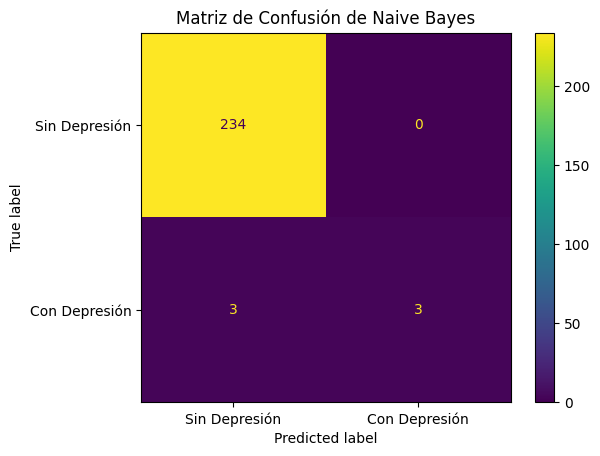

In [129]:
cm = confusion_matrix(y_test, y_pred_nb)
matriz = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Sin Depresión", "Con Depresión"])
matriz.plot()
plt.title("Matriz de Confusión de Naive Bayes")
plt.show()

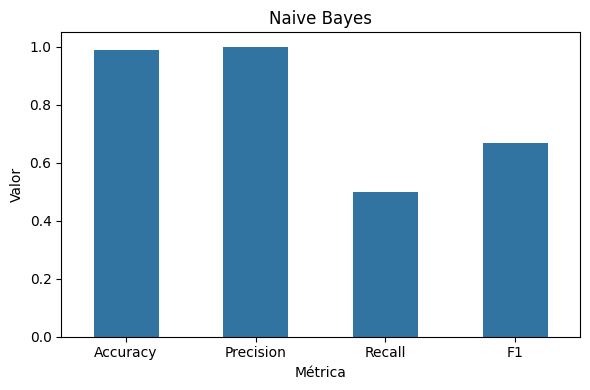

In [130]:
metricas_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1"],
    "Valor": [acc_nb, prec_nb, rec_nb, f1_nb]
})
plt.figure(figsize=(6,4))
sns.barplot(data=metricas_df,x="Métrica",y="Valor", width=0.5)
plt.title("Naive Bayes")
plt.ylabel("Valor")
plt.tight_layout()

## PCA

In [78]:
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

In [79]:
# Varianza explicada 
varianza = pca.explained_variance_ratio_
print(varianza)

[0.1186036  0.10012554 0.08013599 0.07729053 0.07633013 0.07468687
 0.07144371 0.07090641 0.06906537 0.06747012 0.06537221 0.060432
 0.0365252  0.03161233]


In [80]:
# Varianza acumulada
varianza_acumulada = np.cumsum(varianza)
print(varianza_acumulada)

[0.1186036  0.21872914 0.29886513 0.37615566 0.45248579 0.52717266
 0.59861636 0.66952277 0.73858815 0.80605826 0.87143048 0.93186247
 0.96838767 1.        ]


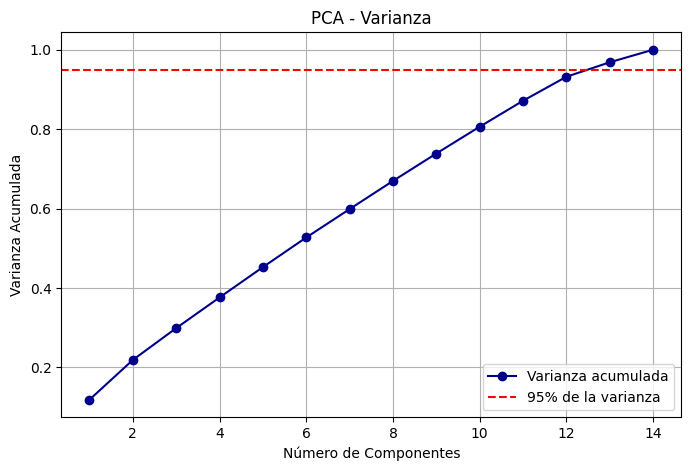

In [91]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,color='darkblue', marker='o', label='Varianza acumulada')
plt.axhline(y=0.95,linestyle='--',color='red',label='95% de la varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('PCA - Varianza')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
n_componentes = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Número de componentes para explicar el 95% de la varianza: {n_componentes}")

Número de componentes para explicar el 95% de la varianza: 13


In [96]:
pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("modelo", LogisticRegression(max_iter=1000))
])
pipeline_pca.fit(x_train, y_train)
y_pred_pca = pipeline_pca.predict(x_test)

In [97]:
print("Número de componentes:", pipeline_pca.named_steps["pca"].n_components_)

Número de componentes: 13


In [99]:
# Metricas del modelo PCA
eigenvalues = pca.explained_variance_
varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)


In [100]:
print("Eigenvalues:", eigenvalues)
print("\nVarianza explicada:", varianza)
print("\nVarianza acumulada:", varianza_acumulada)

Eigenvalues: [1.65399721 1.41553289 1.13563276 1.1114622  1.08676735 1.02426471
 1.02007688 1.0075854  0.93239919 0.91033129 0.89595147 0.86412675
 0.51725963]

Varianza explicada: [0.11801959 0.10100417 0.08103213 0.07930746 0.07754538 0.07308556
 0.07278674 0.07189542 0.06653057 0.06495593 0.06392987 0.06165904
 0.03690863]

Varianza acumulada: [0.11801959 0.21902376 0.30005589 0.37936335 0.45690873 0.52999428
 0.60278102 0.67467644 0.741207   0.80616293 0.8700928  0.93175185
 0.96866048]


## Comparaciones

In [137]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest", "Naive Bayes"],
    "Accuracy": [acc_log, acc_rf, acc_nb],
    "Precision": [prec_log, prec_rf, prec_nb],
    "Recall": [rec_log, rec_rf, rec_nb],
    "F1": [f1_log, f1_rf, f1_nb]
})
resultados

,Modelo,Accuracy,Precision,Recall,F1
0,Regresión Logística,0.987500,1.0,0.500000,0.666667
1,Random Forest,0.979167,1.0,0.166667,0.285714
2,Naive Bayes,0.987500,1.0,0.500000,0.666667


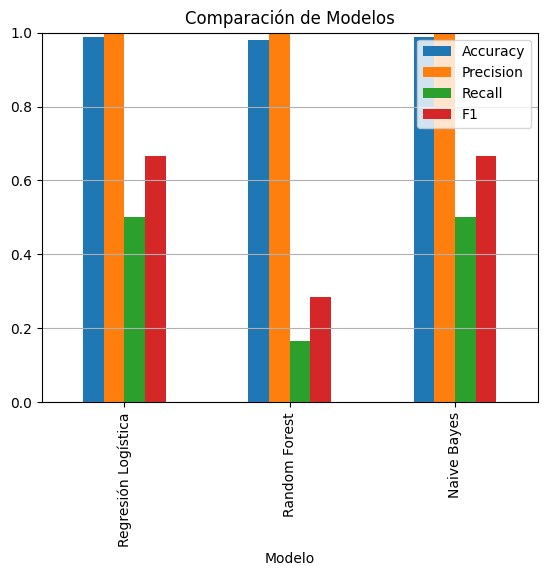

In [138]:
resultados.plot(
    x="Modelo",
    y=["Accuracy", "Precision", "Recall", "F1"],
    kind="bar"
)
plt.ylim(0,1)
plt.title("Comparación de Modelos")
plt.grid(axis="y")
plt.show()